## Notebook 3: Hazard and Exposure 

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
cfg  = C.get("cfg")     # dict loaded from YAML

In [4]:
age_npz = INT / f"age_on_ref_{SLUG}.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"

needed_nb2 = [
    INT / "template_ref.tif",
    INT / "city_mask.tif",
    age_npz,
    pop_npz,
    OUT / f"{SLUG}_fua.gpkg",
    INT / "hazard_manifest.json",
]

missing = [p for p in needed_nb2 if not p.exists()]
if missing:
    raise FileNotFoundError("Re-run Notebook 2. Missing:\n" + "\n".join(map(str, missing)))

**Imports**

In [5]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.transform import array_bounds

from climada.hazard import Hazard, Centroids
from scipy import sparse

plt.rcParams.update({"figure.dpi": 130})

In [6]:
from pathlib import Path
import json, numpy as np, rasterio as rio
import geopandas as gpd

# meta/georef, city mask, age/pop rasters on WBGT grid, FUA, hazard manifest
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
mask_npz  = INT / "city_mask.npz"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"
manifest  = INT / "hazard_manifest.json"
exp_meta  = INT / "exposure_meta.json"

age_npz_candidates = [INT / f"age_on_ref_{SLUG}.npz", INT / "age_on_ref.npz"]
pop_npz_candidates = [INT / f"pop_on_ref_{SLUG}.npz", INT / "pop_on_ref.npz"]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]  

age_npz = first_existing(age_npz_candidates)
pop_npz = first_existing(pop_npz_candidates)

# Template meta
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

# CITY_MASK
if mask_tif.exists():
    with rio.open(mask_tif) as src:
        CITY_MASK = src.read(1).astype(bool)
elif mask_npz.exists():
    CITY_MASK = np.load(mask_npz)["city_mask"].astype(bool)
else:
    raise FileNotFoundError("city_mask.tif/npz not found. Re-run Notebook 2.")

assert CITY_MASK.shape == (HGT, WDT)
ref_data = np.where(CITY_MASK, 0.0, np.nan)

# Age/pop rasters on WBGT grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# metadata for exposures
try:
    year = int(json.load(open(exp_meta))["worldpop_year"])
except Exception:
    year = 2030

# FUA geometry
if not fua_gp.exists():
    raise FileNotFoundError(f"{fua_gp.name} not found. Re-run Notebook 2 to save FUA.")
fua = gpd.read_file(fua_gp, layer="fua")
if fua.empty:
    raise ValueError("FUA is empty.")

# T2M hazard manifest from NB2 
man_path = INT / "hazard_manifest.json"
man = json.load(open(man_path))
assert man.get("hazard_type") == "t2m_daily_mean", f"Unexpected hazard_type: {man.get('hazard_type')}"

years = sorted(map(int, man["files"].keys()))
t2m_paths = {int(y): Path(p) for y, p in man["files"].items()}
print("T2M years:", years)

T2M years: [2030, 2040, 2050]


## Hazard

> **Hazard: daily mean temperature (temperature not days anymore + daily not annual hazard)**
> - Building CLIMADA centroids
> - Assembling daily intensity matrix
> - Defining fraction/footprint
> - CLIMADA hazard building

In [7]:
# DAILY T2M hazard (one event per day)
import xarray as xr
from scipy import sparse
from pyproj import Transformer
from climada.hazard import Hazard, Centroids

# Centroids (grid native is EPSG:3035 so we need to convert to EPSG:4326 for CLIMADA) 
# here we take the UrbClim grid, we compute each cell center, then we convert the coordinates to WBGS83 because CLIMADA's centroids expect lat/lon
# we sanity check to see that one centroid per grid cell
rows, cols = np.indices((HGT, WDT))
xs_m, ys_m = rio.transform.xy(ref_meta["transform"], rows, cols, offset="center")
x_flat = np.asarray(xs_m, float).ravel()   # meters (EPSG:3035)
y_flat = np.asarray(ys_m, float).ravel()
to_wgs84 = Transformer.from_crs(ref_meta["crs"], "EPSG:4326", always_xy=True)
lon, lat = to_wgs84.transform(x_flat, y_flat)
Ctd = Centroids(lat=np.asarray(lat, float), lon=np.asarray(lon, float))

assert (getattr(ref_meta["crs"], "to_epsg", lambda: None)() == 3035), "ref grid not EPSG:3035?"
assert len(Ctd.lat) == HGT*WDT and len(Ctd.lon) == HGT*WDT, "centroids length mismatch"

# building daily intensity rows 
# we assemble the daily intensity matrix 
# for each target year file (°C + masked FUA) we loop over every day
# we extract that day's 2D °C field, keep values inside city mask and set outside to na, we replace na by 0
# we flatten 2D field into one long row: stack all days => big n_days * n_cells matrix in CRS sparse form I_daily
I_rows, dates, years_of = [], [], []
for y in years:
    da = xr.open_dataset(t2m_paths[y])["T2M"]  # (time,y,x) in °C, already masked to FUA in NB2
    for t in da.time.values:
        arr = da.sel(time=t).values
        arr = np.where(CITY_MASK, arr, np.nan)
        I_rows.append(np.nan_to_num(arr, nan=0.0).ravel().astype("float32"))
        d = np.datetime64(t, "D")
        dates.append(d)
        years_of.append(int(str(d)[:4]))

# each row = one day's temperature map
I_daily = sparse.csr_matrix(np.vstack(I_rows))  # shape = (n_days_total, HGT*WDT)

# defining fraction/footprint for each day 
# F_daily: same shape as I_daily but just 0/1 city mask repeated for each day
# in CLIMADA, fraction: what fraction of each cell affected/valid. Here it's 1 inside FUA cell, 0 outside
mask_vec = CITY_MASK.ravel().astype(float)
F_daily = sparse.csr_matrix(np.vstack([mask_vec] * I_daily.shape[0]))

assert I_daily.shape[1] == HGT*WDT, "events x cells shape off"
assert F_daily.shape == I_daily.shape, "fraction footprint mismatch"

# Hazard object (daily events) 
H = Hazard("T2M")
H.haz_type   = "T2M"
H.units      = "degC (daily mean)"
H.orig       = np.array([f"{CITY}_UrbClim_T2Mmean_daily"] * I_daily.shape[0], dtype=object)
H.event_id   = np.array([int(pd.Timestamp(d).strftime("%Y%m%d")) for d in dates], dtype=int)
H.event_name = np.array([f"T2M_{str(d)}" for d in dates], dtype=object)
H.date       = np.array(dates, dtype="datetime64[ns]")
H.frequency  = np.ones(I_daily.shape[0], dtype=float)
H.centroids  = Ctd
H.intensity  = I_daily
H.fraction   = F_daily

H.check()
print(H)

For WBGT, frequency is 1 because it's one year, but here frequency should be 1/year : each day. Frequency is the weight each event has when we convert a list of events into an average per year. If each event is a day, then each day should count as 1/365 (or 1/366 in leap years) so that all days in a year add up to “one year”. If we leave frequency at 1, any “expected annual” metric will be 365× too big.

In [8]:
import numpy as np
import pandas as pd

# years for each event (one row per day)
years = pd.to_datetime(H.date).year.to_numpy()

def days_in_year(y): 
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

H.frequency = np.array([1.0 / days_in_year(y) for y in years], dtype=float)
H.frequency_unit = "1/year"

**plots**

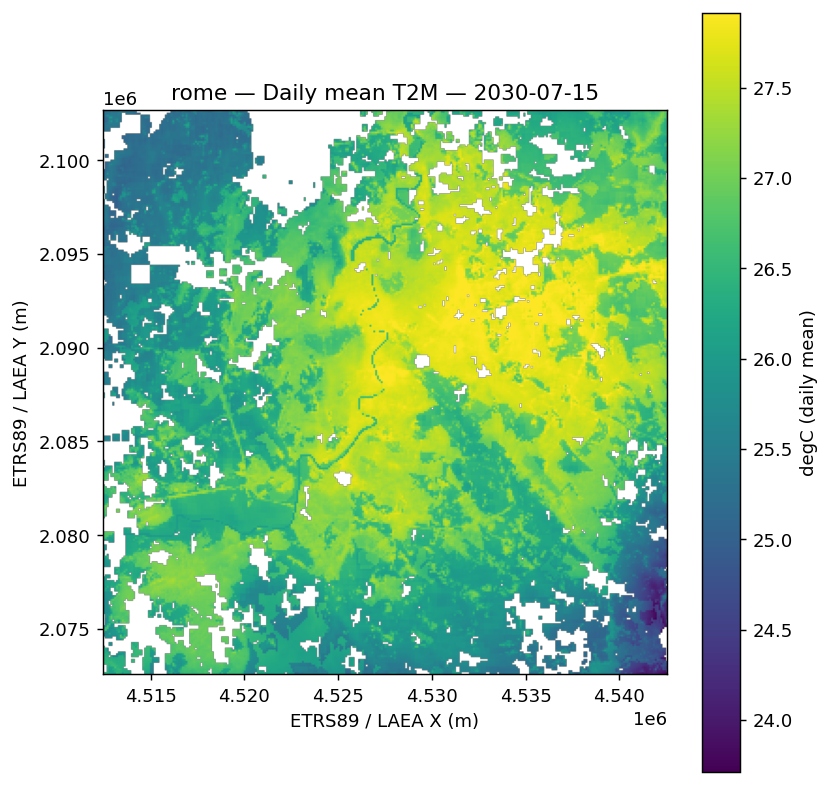

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# Extent (3035, same as rasters)
T = ref_meta["transform"]
left, bottom, right, top = array_bounds(HGT, WDT, T)
extent = (left, right, bottom, top)

def plot_t2m_day(H, date_str):
    d = np.datetime64(date_str, 'D')
    idx = np.where(H.date.astype('datetime64[D]') == d)[0]
    if idx.size == 0:
        raise KeyError(f"No event for {date_str}")
    r = int(idx[0])

    arr = H.intensity.getrow(r).toarray().reshape(HGT, WDT)
    m = np.ma.masked_where(~CITY_MASK, arr)
    vmax = np.nanpercentile(m.compressed(), 99)

    plt.figure(figsize=(6.5, 6.2))
    im = plt.imshow(
        m,
        origin="lower",         
        extent=extent,          
        vmin=m.min(),
        vmax=vmax,
    )
    cb = plt.colorbar(im); cb.set_label("degC (daily mean)")
    plt.title(f"{CITY} — Daily mean T2M — {np.datetime_as_string(d, unit='D')}")
    plt.xlabel("ETRS89 / LAEA X (m)")
    plt.ylabel("ETRS89 / LAEA Y (m)")
    plt.gca().set_aspect('equal', 'box')
    plt.tight_layout(); plt.show()

plot_t2m_day(H, "2030-07-15")

In [13]:
# Per-year frequency sums should be 1
import numpy as np, pandas as pd
yr = pd.to_datetime(H.date).year
chk = pd.Series(H.frequency).groupby(yr).sum()
print(chk)  # expecting 1.0 for 2030, 2040, 2050

# Daily summary: mean of means per year should match yearly_summary
daily = pd.read_csv(INT / f"hazard_events_T2M_daily_{SLUG}.csv", parse_dates=["date"])
print(daily.groupby(daily["date"].dt.year)["frequency"].sum())  # again 1 each year

2030    1.0
2040    1.0
2050    1.0
dtype: float64
date
2030    1.0
2040    1.0
2050    1.0
Name: frequency, dtype: float64


## Exposure on same centroids 

**Aggregating Worldpop to grid**

description: None
ref_year: 2030
value_unit: people
crs: EPSG:4326
data: (233745 entries)
           value age_group  impf_T2M                   geometry
0       0.090981       <15         1  POINT (12.30339 42.00093)
1       0.086432       <15         1   POINT (12.30459 42.0009)
2       0.069341       <15         1  POINT (12.30579 42.00087)
3       0.242386       <15         1  POINT (12.30699 42.00084)
233741  2.596272       65+         3  POINT (12.64865 41.72119)
233742  1.577777       65+         3  POINT (12.64985 41.72115)
233743  0.910779       65+         3  POINT (12.65105 41.72112)
233744  1.150338       65+         3  POINT (12.65224 41.72109)
Total people in exposure (T2M grid): 2548153.9153858856
Breakdown by age group (T2M grid):
age_group
15-64    1.580341e+06
65+      6.906694e+05
<15      2.771438e+05
Name: value, dtype: float64


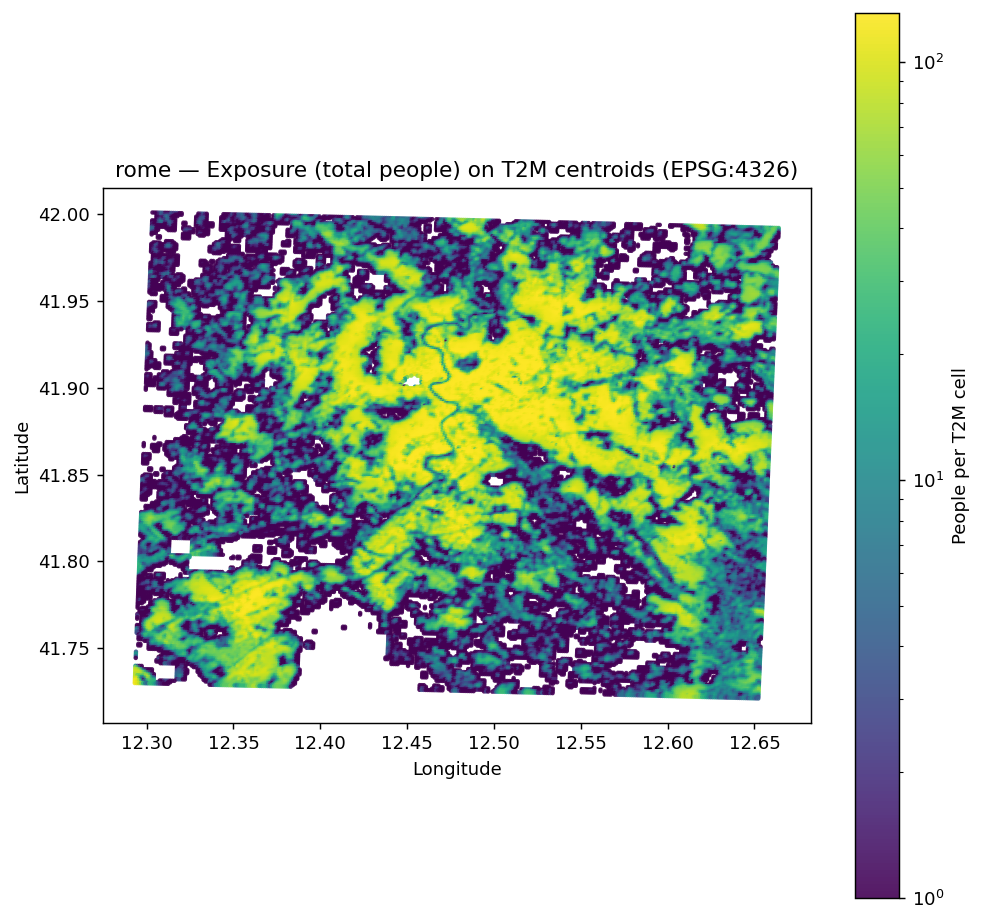

Exposure total (check): 2,548,154 people


In [10]:
# Exposure on same centroids (T2M grid) 

# valid pixels (same mask used for hazard on the T2M grid)
haz_valid = CITY_MASK.ravel()

# IF ids for T2M 
impf_id_T2M = {"<15": 1, "15-64": 2, "65+": 3}

# stack age bands at T2M centroids where pop>0
frames = []
for grp, raster in age_on_ref.items():
    pop_flat = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid = haz_valid & (pop_flat > 0)
    if valid.any():
        frames.append(
            gpd.GeoDataFrame(
                {
                    "value":     pop_flat[valid],
                    "longitude": lon[valid],    # lon from the T2M centroids built
                    "latitude":  lat[valid],    # lat from the T2M centroids built
                    "age_group": np.full(valid.sum(), grp, dtype=object),
                    "impf_T2M":  np.full(valid.sum(), impf_id_T2M[grp], dtype=int),
                },
                geometry=gpd.points_from_xy(lon[valid], lat[valid]),
                crs="EPSG:4326",
            )
        )

gdf = pd.concat(frames, ignore_index=True) if frames else gpd.GeoDataFrame(
    columns=["value","longitude","latitude","age_group","impf_T2M","geometry"], crs="EPSG:4326"
)

# CLIMADA Exposures
from climada.entity.exposures import Exposures
exp = Exposures()
exp.set_gdf(gdf)
exp.value_unit = "people"
exp.ref_year   = year
exp.tag        = f"{CITY} FUA — WorldPop age groups ({year}) on T2M (UrbClim) grid"
exp.check()

print(exp)
if not exp.gdf.empty:
    print("Total people in exposure (T2M grid):", float(exp.gdf["value"].sum()))
    print("Breakdown by age group (T2M grid):")
    print(exp.gdf.groupby("age_group")["value"].sum().astype(float))

# map (people per T2M cell)
from matplotlib.colors import LogNorm
vals_all  = np.nan_to_num(pop_on_ref, nan=0.0)
valid_all = CITY_MASK
vmax = np.nanpercentile(vals_all[valid_all], 99) if valid_all.any() else 1.0
norm = LogNorm(vmin=1, vmax=max(1.0, vmax))

plt.figure(figsize=(7.8, 7.2))
sc = plt.scatter(lon[valid_all.ravel()], lat[valid_all.ravel()],
                 c=vals_all.ravel()[valid_all.ravel()], s=6, linewidths=0, alpha=0.9, norm=norm)
cb = plt.colorbar(sc); cb.set_label("People per T2M cell")
plt.title(f"{CITY} — Exposure (total people) on T2M centroids (EPSG:4326)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

print(f"Exposure total (check): {vals_all[valid_all].sum():,.0f} people")

**Save for future notebooks**

In [11]:
# saving daily hazard + exposures
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# row-date map (HDF5 drops date/event_name)
dates_df = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date).astype(str),
})
dates_csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
dates_df.to_csv(dates_csv, index=False)
print("Saved events map →", dates_csv)

# daily summary (one row per day)
mean_by_event = np.asarray(H.intensity.mean(axis=1)).ravel()  # citywide mean °C per day
daily_summary = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date),
    "frequency": np.asarray(H.frequency, dtype=float),
    "mean_intensity_degC": mean_by_event,
})
daily_csv = INT / f"hazard_events_T2M_daily_{SLUG}.csv"
daily_summary.to_csv(daily_csv, index=False)
print("Saved daily summary →", daily_csv)

# if we needed also a yearly summary (aggregate daily to year)
yearly_summary = (
    daily_summary
    .assign(year=lambda d: d["date"].dt.year.astype(int))
    .groupby("year", as_index=False)
    .agg(
        n_days=("row", "count"),
        citymean_degC=("mean_intensity_degC", "mean")
    )
)
yearly_csv = INT / f"hazard_events_T2M_yearly_{SLUG}.csv"
yearly_summary.to_csv(yearly_csv, index=False)
print("Saved yearly summary →", yearly_csv)

2025-11-14 13:00:27,401 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_T2M_daily_rome.h5 | days: 1096
Saved events map → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_T2M_daily_events_rome.csv
Saved daily summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_events_T2M_daily_rome.csv
Saved yearly summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_events_T2M_yearly_rome.csv


In [14]:
# saving daily hazard + exposures
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# also copy to OUT so other notebooks can find it easily
import shutil
haz_path_out = OUT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path_out = OUT / f"exposure_people_{SLUG}.h5"
haz_path_out.parent.mkdir(parents=True, exist_ok=True)
exp_path_out.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(haz_path, haz_path_out)
shutil.copy2(exp_path, exp_path_out)
print("Copied to OUT →", haz_path_out)
print("Copied to OUT →", exp_path_out)

2025-11-14 13:04:46,096 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/hazard_T2M_daily_rome.h5 | days: 1096
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/hazard_T2M_daily_rome.h5
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/exposure_people_rome.h5


In [16]:
import numpy as np
import pandas as pd
import rasterio as rio

# loading grid shape from template_ref.tif
tmpl_path = INT / "template_ref.tif"
with rio.open(tmpl_path) as src:
    HGT, WDT = src.height, src.width

n_days, n_cells = H.intensity.shape
assert n_cells == HGT * WDT, f"Cells {n_cells} != HGT*WDT = {HGT*WDT}"

# Year per event
dates = pd.to_datetime(pd.Series(H.date))
years = dates.dt.year.to_numpy().astype(int)
uniq_years = np.unique(years)

# For each year, computing mean daily T2M per cell and reshape to 2D
DATA = np.empty((len(uniq_years), HGT, WDT), dtype="float32")
for k, yr in enumerate(uniq_years):
    mask = (years == yr)
    # mean over days in that year => one value per cell
    arr_1d = np.asarray(H.intensity[mask].mean(axis=0), dtype="float32")
    DATA[k, :, :] = arr_1d.reshape(HGT, WDT)

# saving as npz 
t2m_npz_path = INT / f"t2m_hazard_2030_2100_{SLUG}.npz"
np.savez_compressed(t2m_npz_path, years=uniq_years, data=DATA)
print("Saved yearly T2M hazard grid →", t2m_npz_path)

Saved yearly T2M hazard grid → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/t2m_hazard_2030_2100_rome.npz
